Dataset Shape:
accuracyScore  0.8019872249822569
classificationReport                precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

[[937  98]
 [181 193]]


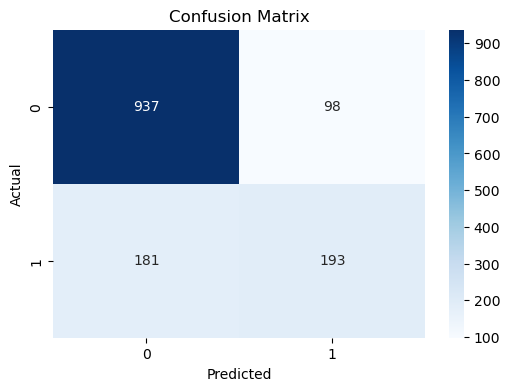

gender   0.015381901716606054
SeniorCitizen   0.013386486497458478
Partner   0.013659683481028884
Dependents   0.014174101624929101
tenure   0.16391025234330048
PhoneService   0.005160021687943312
MultipleLines   0.020645225195944188
InternetService   0.045523231773449586
OnlineSecurity   0.0824323075043662
OnlineBackup   0.029110544212992598
DeviceProtection   0.01803993904325549
TechSupport   0.062454392068594045
StreamingTV   0.013835172173303798
StreamingMovies   0.014057143549909543
Contract   0.13935299004820748
PaperlessBilling   0.02426871420884868
PaymentMethod   0.04306863098243809
MonthlyCharges   0.13548807961896175
TotalCharges   0.14605118226846234
cv_score  [0.80979418 0.80908446 0.77927608 0.80752841 0.80397727]

Average CV Accuracy: 80.19 %


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

df = pd.read_csv(r"D:\Python-Course\ML-Course\test\Kaggle\Random-Forest-Telco-Customer-Churn.csv")
print("Dataset Shape:")
# print(df.shape)
# print(df.info())

df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"] == df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

for column in df.columns:
    if df[column].dtype == 'object':
            le = LabelEncoder()
            df[column] = le.fit_transform(df[column]) 

# print(df.head())
x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,  stratify=y)

rf_model = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 10,
        min_samples_split = 5,
        min_samples_leaf = 2,
        random_state=42,
        n_jobs = -1
)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[:,1]
accuracyScore = accuracy_score(y_test, y_pred)
print('accuracyScore ',accuracyScore)
classificationReport = classification_report(y_test, y_pred)
print('classificationReport ', classificationReport)
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
feature_importances = rf_model.feature_importances_
for feature, imp in zip(x.columns, feature_importances):
    print(feature, ' ' , imp)
cv_score = cross_val_score(
                    rf_model,
                    x,
                    y,
                    cv=5,
                    scoring = 'accuracy'
                )
print('cv_score ',cv_score)
print("\nAverage CV Accuracy:", round(cv_score.mean()*100, 2), "%")
with open(r'D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\Random-Forest\random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)